# Model Interpretability and Feature Analysis

This notebook explains how the trained models make predictions, using feature importance analysis and SHAP (SHapley Additive exPlanations) values. Understanding model decisions is crucial in healthcare applications.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

sys.path.append(str(Path.cwd().parent / 'src'))
from data_loader import load_cdc_diabetes_data

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 7), 'figure.dpi': 100})

MODELS_DIR = Path.cwd().parent / 'models'
OUTPUT_DIR = Path.cwd().parent / 'images'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load data and best model

In [2]:
X, y, df = load_cdc_diabetes_data()
print(f"Dataset shape: {df.shape}")
print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

# Load best model from previous notebook
best_model_path = MODELS_DIR / "best_model.joblib"
if best_model_path.exists():
    best_model = joblib.load(best_model_path)
    print(f"\n✅ Loaded best model from {best_model_path}")
else:
    print("⚠️  Best model not found. Training a new model...")
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import GradientBoostingClassifier
    
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="passthrough"
    )
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    
    best_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ])
    
    best_model.fit(X_train, y_train)
    print(f"Model trained! Accuracy: {best_model.score(X_test, y_test):.4f}")

Dataset shape: (253680, 22)
Features: 21
Target distribution:
0    218334
1     35346
Name: Diabetes_binary, dtype: int64

✅ Loaded best model from /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/models/best_model.joblib


## Feature Importance Analysis

Tree-based models (like Gradient Boosting) provide feature importance scores based on how much each feature contributes to reducing prediction errors.

Top 10 Most Important Features:
                 Feature  Importance
13               GenHlth    0.296949
0                 HighBP    0.263014
3                    BMI    0.172032
18                   Age    0.080415
1               HighChol    0.079503
16              DiffWalk    0.038410
6   HeartDiseaseorAttack    0.024489
20                Income    0.011960
10     HvyAlcoholConsump    0.011513
17                   Sex    0.006409


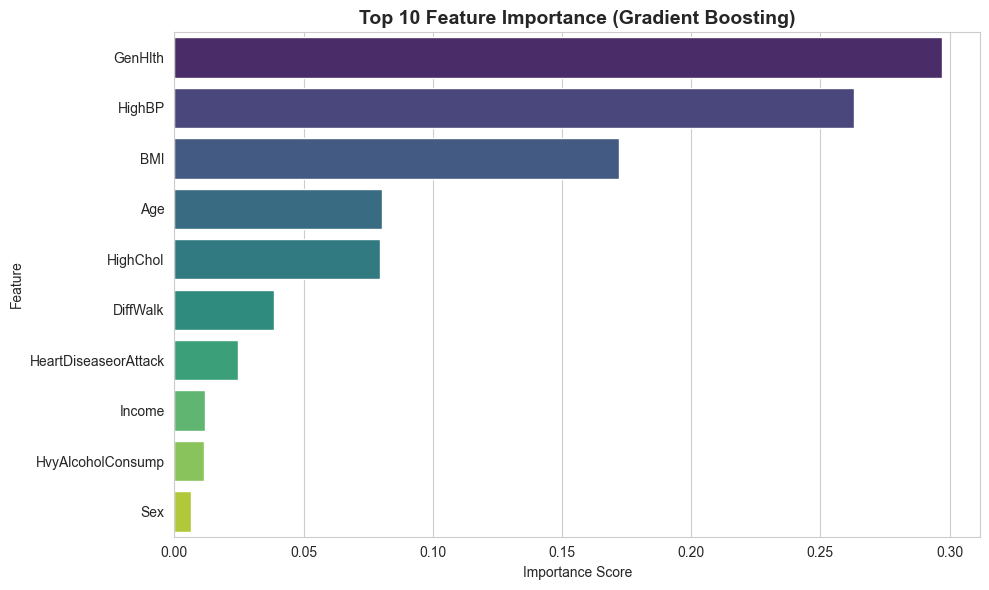

In [3]:
# Extract the classifier from the pipeline
classifier = best_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    feature_importance = classifier.feature_importances_
    feature_names = X.columns
    
    # Create a dataframe for better visualization
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance
    }).sort_values("Importance", ascending=False)
    
    print("Top 10 Most Important Features:")
    print(importance_df.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(10), x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title("Top 10 Feature Importance (Gradient Boosting)", fontsize=14, fontweight="bold")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Model does not have feature_importances_ attribute")

## SHAP (SHapley Additive exPlanations) Values

SHAP values provide a theoretically sound way to interpret individual predictions. Each feature is assigned a value that represents its contribution to pushing the prediction away from the base value.

✅ SHAP values computed
Shape of SHAP values: (50736, 21)


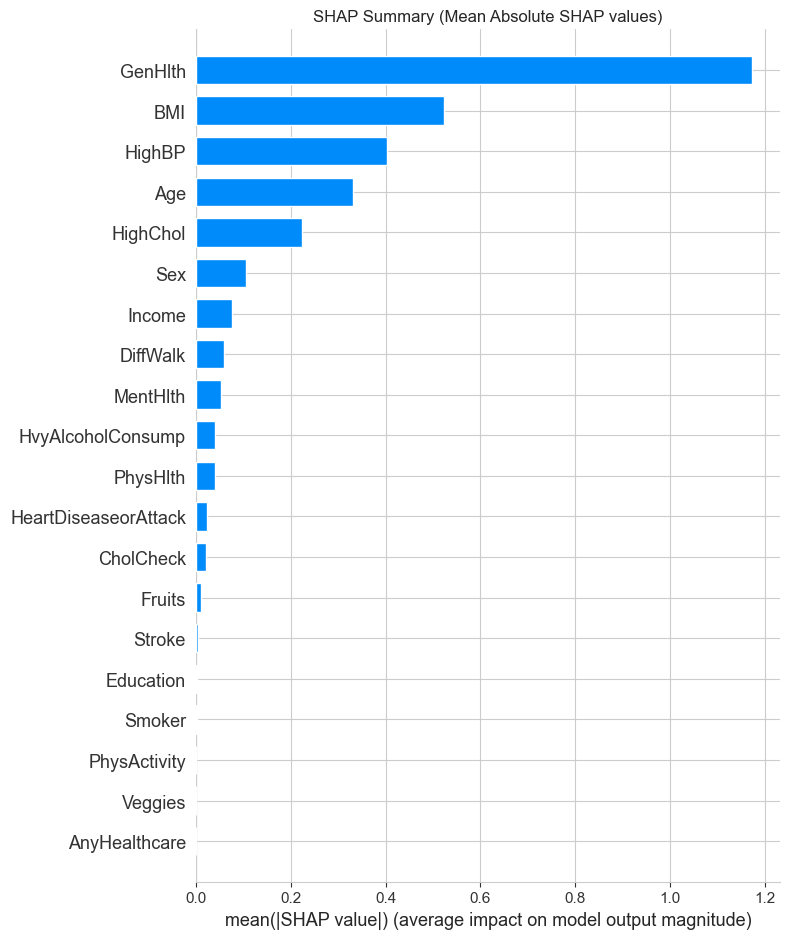


✅ SHAP summary plot saved


In [4]:
# Prepare data for SHAP
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Create SHAP explainer for the classifier
try:
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test)
    
    print("✅ SHAP values computed")
    print(f"Shape of SHAP values: {np.array(shap_values).shape}")
    
    # For binary classification, shap_values might be a list with 2 elements (one for each class)
    # We take the values for the positive class (diabetes=1)
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_test, plot_type="bar", show=False)
    plt.title("SHAP Summary (Mean Absolute SHAP values)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "shap_summary_bar.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("\n✅ SHAP summary plot saved")
except Exception as e:
    print(f"Note: SHAP analysis could not be completed: {e}")

## Individual Prediction Explanation

For a healthcare application, it is important to understand why the model makes a specific prediction for an individual patient.

In [5]:
# Select a sample to explain
sample_idx = 0  # First test sample
sample = X_test.iloc[[sample_idx]]
sample_shap_values = shap_vals[sample_idx]

# Get prediction
prediction = best_model.predict(sample)[0]
prediction_proba = best_model.predict_proba(sample)[0]

print(f"Sample {sample_idx} Characteristics:")
print(sample.T)
label = "Yes" if prediction == 1 else "No"
print(f"Predicted Class: {prediction} (Diabetes: {label})")
print(f"Prediction Probability: {prediction_proba}")
print(f"\nTop Contributing Features to this Prediction:")

# Get top contributing features
feature_impact = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Value": sample_shap_values,
    "Feature_Value": sample.values.flatten()
}).sort_values("SHAP_Value", ascending=False, key=abs)

print(feature_impact.head(5))

Sample 0 Characteristics:
                      128677
HighBP                     1
HighChol                   1
CholCheck                  1
BMI                       28
Smoker                     0
Stroke                     0
HeartDiseaseorAttack       0
PhysActivity               1
Fruits                     1
Veggies                    1
HvyAlcoholConsump          0
AnyHealthcare              1
NoDocbcCost                0
GenHlth                    3
MentHlth                   0
PhysHlth                   0
DiffWalk                   0
Sex                        1
Age                        5
Education                  5
Income                     8
Predicted Class: 0 (Diabetes: No)
Prediction Probability: [0.84915611 0.15084389]

Top Contributing Features to this Prediction:
     Feature  SHAP_Value  Feature_Value
13   GenHlth    1.269831              3
0     HighBP    0.492940              1
3        BMI    0.465487             28
18       Age    0.249567              5
1   Hig

## Model Reliability and Confidence

In healthcare, not only should we know what a model predicts, but also how confident we should be in that prediction.

Mean Prediction Confidence: 0.8682
Std Dev: 0.1343
Min: 0.5000
Max: 0.9972


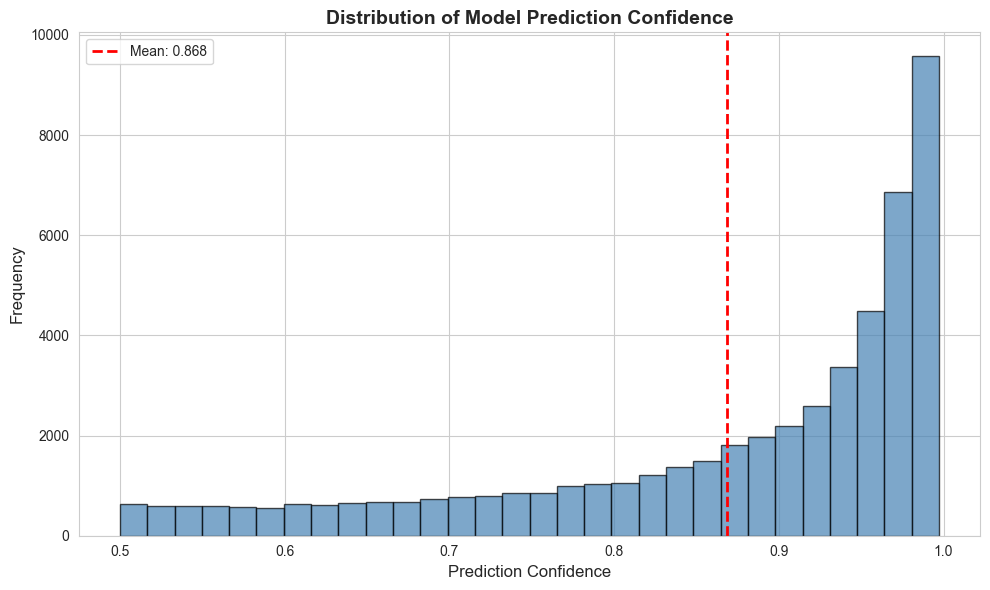

In [6]:
# Calculate prediction confidence
probabilities = best_model.predict_proba(X_test)
confidence = np.max(probabilities, axis=1)

print(f"Mean Prediction Confidence: {confidence.mean():.4f}")
print(f"Std Dev: {confidence.std():.4f}")
print(f"Min: {confidence.min():.4f}")
print(f"Max: {confidence.max():.4f}")

# Visualize confidence distribution
plt.figure(figsize=(10, 6))
plt.hist(confidence, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.xlabel("Prediction Confidence", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Model Prediction Confidence", fontsize=14, fontweight="bold")
plt.axvline(confidence.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {confidence.mean():.3f}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prediction_confidence.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

This notebook demonstrated:
- **Feature Importance**: Understanding which features drive model predictions
- **SHAP Values**: A theoretically grounded approach to feature attribution
- **Individual Explanations**: Why the model makes a specific prediction
- **Prediction Confidence**: Assessing how certain the model is

These interpretability tools are essential for building trust in ML models for healthcare applications.